In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [64]:
df = pd.read_csv("./data/VALE3_2025(in).csv")
df

,Date,LastPrice
0,"30.12.2025,""71,96""",NaN
1,"29.12.2025,""72,12""",NaN
2,"26.12.2025,""73,12""",NaN
3,"23.12.2025,""72,90""",NaN
4,"22.12.2025,""72,92""",NaN
...,...,...
245,"08.01.2025,""51,55""",NaN
246,"07.01.2025,""52,05""",NaN
247,"06.01.2025,""52,56""",NaN
248,"03.01.2025,""53,24""",NaN


# Questão 1

In [68]:
df = pd.read_csv('./data/VALE3_2025(in).csv')

def clean_data(df):
    loc = df.columns.get_loc("Date")
    df_split = df["Date"].str.split(",", n=1, expand=True).add_prefix("Date_")
    df = pd.concat([df.iloc[:, :loc], df_split, df.iloc[:, loc + 1:]], axis=1)
    df.insert(2, "derivedCol", df["Date_1"].str.replace('"', ""))
    return df

df = clean_data(df.copy())

df["LastPrice"] = df["derivedCol"].str.replace(',', '.').astype(float)
df["Date"] = pd.to_datetime(df["Date_0"], format='%d.%m.%Y')
df = df.drop(columns=["Date_1", "derivedCol", "Date_0"])
df = df.sort_values(by="Date", ascending=False)
df

,LastPrice,Date
0,71.96,2025-12-30
1,72.12,2025-12-29
2,73.12,2025-12-26
3,72.90,2025-12-23
4,72.92,2025-12-22
...,...,...
245,51.55,2025-01-08
246,52.05,2025-01-07
247,52.56,2025-01-06
248,53.24,2025-01-03


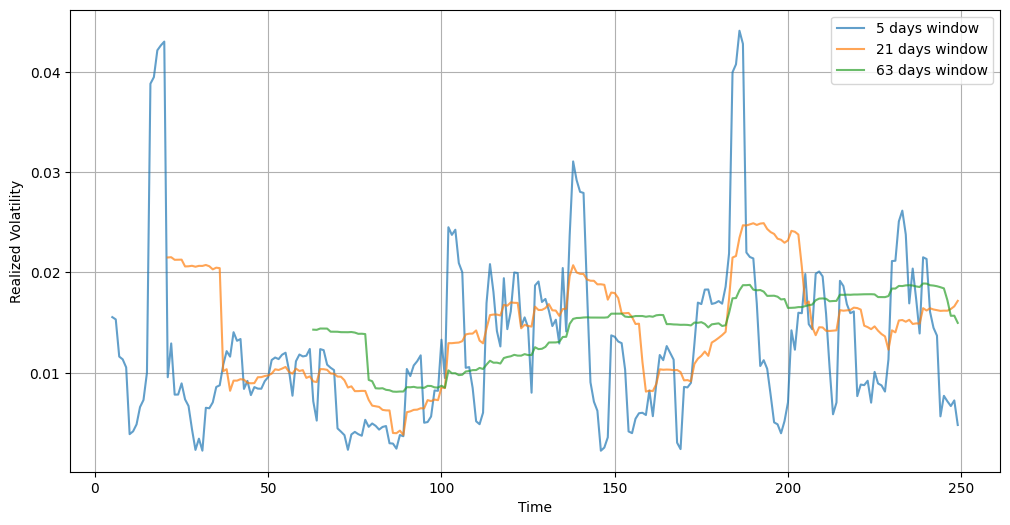

In [66]:
df['Returns'] = df['LastPrice'].pct_change()

df['RV_5'] = df['Returns'].rolling(window=5).std()
df['RV_21'] = df['Returns'].rolling(window=21).std()
df['RV_63'] = df['Returns'].rolling(window=63).std()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['RV_5'], label='5 days window', alpha=0.7)
plt.plot(df.index, df['RV_21'], label='21 days window', alpha=0.7)
plt.plot(df.index, df['RV_63'], label='63 days window', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Realized Volatility')
plt.legend()
plt.grid(True)
plt.show()

In [75]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

class BlackScholesEngine:
    """
    Motor de precificação baseado no artigo de Black-Scholes (Haugh, 2016).
    Implementa as fórmulas de precificação e sensibilidades (Gregos).
    """
    
    @staticmethod
    def calculate_d1_d2(S, K, T, r, sigma, q=0):
        # Implementação das equações (9) e (13) do PDF [cite: 43, 44, 81, 82]
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return d1, d2

    def price_option(self, S, K, T, r, sigma, q=0, option_type='call'):
        """Calcula o preço justo (Prêmio) da opção[cite: 42, 80]."""
        d1, d2 = self.calculate_d1_d2(S, K, T, r, sigma, q)
        
        if option_type.lower() == 'call':
            # Equação (13) para Call com dividendos [cite: 80]
            price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        else:
            # Preço da Put via Paridade Put-Call [cite: 47, 218]
            price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
        return price

    def calculate_greeks(self, S, K, T, r, sigma, q=0, option_type='call'):
        """Calcula as sensibilidades (Greeks)[cite: 228, 301, 347, 386]."""
        d1, d2 = self.calculate_d1_d2(S, K, T, r, sigma, q)
        
        # Delta: Sensibilidade ao preço (S) [cite: 229]
        if option_type.lower() == 'call':
            delta = np.exp(-q * T) * norm.cdf(d1)
        else:
            delta = np.exp(-q * T) * (norm.cdf(d1) - 1)
            
        # Gamma: Sensibilidade do Delta (S^2) [cite: 301]
        gamma = (np.exp(-q * T) * norm.pdf(d1)) / (S * sigma * np.sqrt(T))
        
        # Vega: Sensibilidade à Volatilidade (sigma) [cite: 347]
        vega = S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1)
        
        # Theta: Sensibilidade ao tempo (T) [cite: 386]
        term1 = -(S * sigma * np.exp(-q * T) * norm.pdf(d1)) / (2 * np.sqrt(T))
        if option_type.lower() == 'call':
            theta = term1 - r * K * np.exp(-r * T) * norm.cdf(d2) + q * S * np.exp(-q * T) * norm.cdf(d1)
        else:
            theta = term1 + r * K * np.exp(-r * T) * norm.cdf(-d2) - q * S * np.exp(-q * T) * norm.cdf(-d1)
            
        return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta}
    
    def calculate_forward(self, S, r, q, T):
        forward_price = S*(np.exp((r-q)*T))
        return forward_price

# --- EXEMPLO DE USO PARA A DINÂMICA ---
if __name__ == "__main__":
    bs = BlackScholesEngine()
    
    # Parâmetros de exemplo (Ajuste conforme o case)
    S = 55    # Preço da ação agora
    K = 54.02    # Strike (At-the-money)
    T = 239/365     # 1 ano até o vencimento
    # r = 0.15/365     # Juros de 10%
    r = 0.0003829
    sigma = 0.101  # Volatilidade de 20%
    q = .0856/365
    
    print(f"--- ANÁLISE DE OPÇÃO ---")
    call_p = bs.price_option(S, K, T, r, sigma, q, option_type='call')
    put_p = bs.price_option(S, K, T, r, sigma, q, option_type='put')
    forward_price = bs.calculate_forward(S, r, q, T)
    greeks = bs.calculate_greeks(S, K, T, r, sigma, q, option_type='call')
    
    print(f"Preço da Call: R$ {call_p:.5f}")
    print(f"Preço da Put: R$ {put_p:.5f}")
    print(f"Preço de Forward: R$ {forward_price:.2f}")

    for greek, valor in greeks.items():
        print(f"{greek}: {valor:.4f}")

--- ANÁLISE DE OPÇÃO ---
Preço da Call: R$ 2.31224
Preço da Put: R$ 1.32714
Preço de Forward: R$ 55.01
Delta: 0.6033
Gamma: 0.0857
Vega: 17.1533
Theta: -1.3270


# 4 - Conclusões

* O P&L da terceira questão letra A vai ser:

Para a Call
$$ 
- c + s - k
$$

Para a Put
$$ 
- p
$$